In [286]:
from torchdiffeq import odeint
from importlib import reload
import CNF
import torch
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles

DEVICE = "cpu"

In [278]:
reload(CNF)

<module 'CNF' from '/home/alekseyka/projects/science school/CNF.py'>

In [301]:
def get_batch(n: int):
    X, _ = make_circles(n, noise=0.06, factor=0.5)
    return torch.tensor(X)

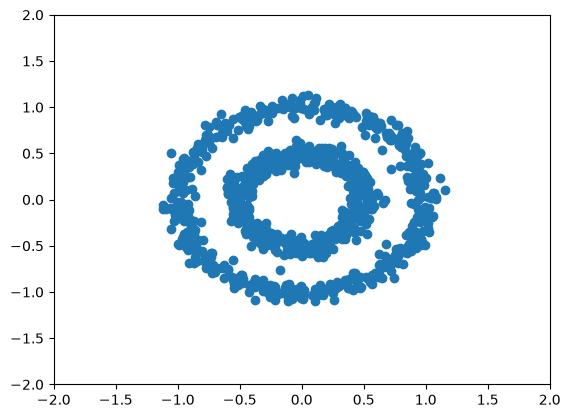

In [305]:
fig, ax = plt.subplots()

# Координаты сетки
X = get_batch(1000)
X = X.numpy()
x, y = X[:, 0], X[:, 1]
ax.scatter(x, y)
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)
# plt.colorbar()
plt.show()

In [279]:
# cpnf: CNF.Cpnf = CNF.Cpnf(2)
# cpnf.to(DEVICE)
hidden_features = 64
filds_num = 4
cpnflist = torch.nn.ModuleList([CNF.Cpnf(2).to(DEVICE) for i in range(filds_num)])
time_gates = torch.nn.ModuleList([torch.nn.Sequential(torch.nn.Linear(1, hidden_features),
                                  torch.nn.Sigmoid(),
                                  torch.nn.Linear(hidden_features, 1)) for i in range(filds_num)])
cnf = CNF.CNF(fields=cpnflist, activations=time_gates)
wraped = CNF.Wraper(cnf)

In [280]:
Y, jac = wraped.forward(torch.tensor([[0., 1], [1, 0], [1, 1]]), log_jac=True)
Y1 = wraped.forward(torch.tensor([[0., 1], [1, 0], [1, 1]]))
Y, jac, Y1


(tensor([[ 0.7238,  0.8344],
         [ 1.7132, -0.1187],
         [ 1.6900,  0.8660]]),
 tensor([ 0.2030, -0.0355, -0.0175]),
 tensor([[ 0.7238,  0.8344],
         [ 1.7132, -0.1187],
         [ 1.6900,  0.8660]]))

In [281]:
def density(X):
    distribution = torch.distributions.MultivariateNormal(torch.zeros(2), torch.eye(2))
    Y, logprop = wraped.forward(X, log_jac=True)
    return distribution.log_prob(Y) - logprop

In [241]:
a = wraped.field.u.detach()
b = wraped.field.b.detach()
a, b

(tensor([0.3038, 1.6246]), tensor([0.1144]))

In [244]:
with torch.no_grad():
    wraped.field.u.set_(a.detach())
    wraped.field.b.set_(b.detach()*0)

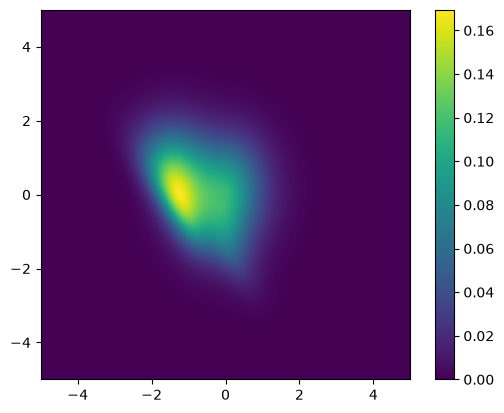

In [307]:
# fig, ax = plt.subplots()

# Координаты сетки
x = torch.linspace(-5, 5, 200)
y = torch.linspace(-5, 5, 200)

X, Y = torch.meshgrid(x, y, indexing="xy")

# Форма: (200 * 200, 2)
points = torch.stack([X.flatten(), Y.flatten()], dim=1)
# print(points, points.shape)
points = points.detach()

# Твоя функция принимает (batch_size, 2)
Z = density(points)

# Возвращаем результат к форме сетки
Z = Z.reshape(200, 200)
Z = torch.exp(Z)

plt.imshow(
    Z.numpy(),
    extent=[-5, 5, -5, 5],
    origin="lower",
    aspect="equal",
)
plt.colorbar()
plt.show()